# LSTM model with real price as only variable

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import random
import itertools
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error



def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

In [25]:
# import wti price data
wti = pd.read_csv('../data/wti_prices.csv')

# take log difference of wti 
wti['log_diff'] = np.log(wti['WTI_price']).diff()

# drop the first row with NaN log difference
wti = wti.dropna().reset_index(drop=True)

wti.head()


,Date,WTI_price,log_diff
0,1986-02-01,15.46,-0.394190
1,1986-03-01,12.61,-0.203766
2,1986-04-01,12.84,0.018075
3,1986-05-01,15.38,0.180503
4,1986-06-01,13.43,-0.135577


In [26]:
# data split into 70/15/15
train_size = int(len(wti) * 0.7)
val_size = int(len(wti) * 0.15)
val_end = train_size + val_size


train_data = wti['log_diff'][:train_size].values
val_data = wti['log_diff'][train_size:train_size + val_size].values
test_data = wti['log_diff'][train_size + val_size:].values

# print length of data in each set
print(f'Train data length: {len(train_data)}')
print(f'Validation data length: {len(val_data)}')
print(f'Test data length: {len(test_data)}')

Train data length: 336
Validation data length: 72
Test data length: 72


In [27]:
def build_lstm_model(lookback, n_features, units, dropout, lr=0.001):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features), return_sequences=True),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )
    
    return model

# model architecture inspired by Ly et al. (2021) "Forecasting Commodity Prices Using Long-Short-Term Memory Neural Networks" 
# using a single LSTM layer with 50 units, dropout of 0.1, and learning rate of 0.001
def build_lstm_model_paper(lookback, n_features, units=50, dropout=0.1, lr=0.001):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )

    return model

In [28]:
# Create sequences from a dataframe
# X_t uses rows [t-lookback, ..., t-1]
# y_t uses row t

def create_sequences(data, feature_cols, target_col, lookback):
    X, y = [], []

    values_x = data[feature_cols].values
    values_y = data[target_col].values

    for t in range(lookback, len(data)):
        X.append(values_x[t - lookback:t])
        y.append(values_y[t])

    return np.array(X), np.array(y)

In [29]:
def expanding_window_lstm_forecast(
    df,
    feature_cols,
    target_col,
    date_col=None,
    initial_train_size=200,
    end_idx=None,
    lookback=20,
    units=50,
    dropout=0.2,
    epochs=20,
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
):
    """
    Expanding window one-step-ahead forecast using LSTM.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataframe in time order.
    feature_cols : list
        Input feature columns.
    target_col : str
        Target column to predict.
    date_col : str or None
        Optional date column to keep in output.
    initial_train_size : int
        First forecast origin. Training uses all rows before this index.
    end_idx : int or None
        Forecast until this index (exclusive). If None, forecast to end of df.
    lookback : int
        Number of past timesteps per sequence.
    units, dropout, epochs, batch_size : model/training params
    verbose : int
        Keras fit verbosity.
    scale : bool
        Whether to fit StandardScaler on training data at each step.
    seed : int
        Random seed.

    Returns
    -------
    pd.DataFrame
        DataFrame with forecast date, actual, predicted.

    Notes
    -----
    - This method is computationally expensive because it retrains the model at each step.
    - We use an expanding window approach where the model is trained on all data
      available up to the current time, converted into overlapping lookback sequences.
    - Each prediction uses only the most recent sequence, but model parameters are
      estimated using all past sequences.
    - Scaling is done within each training step to prevent leakage. Scalers are fit
      only on the training data and then applied to the prediction sequence.
    """
    set_seed(seed)

    results = []
    df = df.copy().reset_index(drop=True)

    start_idx = max(initial_train_size, lookback)
    stop_idx = end_idx if end_idx is not None else len(df)

    for test_idx in range(start_idx, stop_idx):
        # all data up to test_idx - 1
        train_df = df.iloc[:test_idx].copy()

        if scale:
            x_scaler = StandardScaler()
            y_scaler = StandardScaler()

            train_df[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
            train_df[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])

        # build training sequences
        X_train, y_train = create_sequences(train_df, feature_cols, target_col, lookback)

        if len(X_train) == 0:
            continue

        # latest sequence: [test_idx-lookback, ..., test_idx-1]
        hist_window = df.iloc[test_idx - lookback:test_idx].copy()

        if scale:
            hist_window[feature_cols] = x_scaler.transform(hist_window[feature_cols])

        X_test = hist_window[feature_cols].values.reshape(1, lookback, len(feature_cols))

        tf.keras.backend.clear_session()
        model = build_lstm_model(
            lookback=lookback,
            n_features=len(feature_cols),
            units=units,
            dropout=dropout
        )

        early_stop = EarlyStopping(
            monitor="loss",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=verbose,
            callbacks=[early_stop]
        )

        pred = model.predict(X_test, verbose=0).flatten()[0]

        if scale:
            pred = y_scaler.inverse_transform([[pred]])[0, 0]

        actual = df.iloc[test_idx][target_col]

        result = {
            "test_index": test_idx,
            "actual": actual,
            "predicted": pred
        }

        if date_col is not None:
            result[date_col] = df.iloc[test_idx][date_col]

        results.append(result)

    return pd.DataFrame(results)

In [17]:
# grid search over hyperparameters for the expanding window LSTM
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
} 
param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    try:
        val_forecasts = expanding_window_lstm_forecast(
            df=wti,
            feature_cols=["log_diff"],
            target_col="log_diff",
            initial_train_size=train_size,
            end_idx=val_end,
            lookback=lb,
            units=units,
            dropout=dr,
            epochs=ep,
            batch_size=32,
            verbose=0,
            scale=True,
            seed=42
        )

        if len(val_forecasts) == 0:
            print("No forecasts generated, skipping.")
            continue

        mse = mean_squared_error(
            val_forecasts["actual"],
            val_forecasts["predicted"]
        )

        print(f"Validation MSE: {mse:.6f}")

        results_grid.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep,
            "mse": mse
        })

    except Exception as e:
        print(f"Error: {e}")
        continue



[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50


2026-03-27 16:18:57.425803: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Validation RMSE: 0.076598

[2/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=100
Validation RMSE: 0.076588

[3/16] Testing params:
lookback=2, dropout=0.001, units=170, epochs=50
Validation RMSE: 0.073955

[4/16] Testing params:
lookback=2, dropout=0.001, units=170, epochs=100
Validation RMSE: 0.073955

[5/16] Testing params:
lookback=2, dropout=0.1, units=50, epochs=50
Validation RMSE: 0.075659

[6/16] Testing params:
lookback=2, dropout=0.1, units=50, epochs=100
Validation RMSE: 0.075659

[7/16] Testing params:
lookback=2, dropout=0.1, units=170, epochs=50
Validation RMSE: 0.075554

[8/16] Testing params:
lookback=2, dropout=0.1, units=170, epochs=100
Validation RMSE: 0.075554

[9/16] Testing params:
lookback=10, dropout=0.001, units=50, epochs=50
Validation RMSE: 0.222621

[10/16] Testing params:
lookback=10, dropout=0.001, units=50, epochs=100
Validation RMSE: 0.222406

[11/16] Testing params:
lookback=10, dropout=0.001, units=170, epochs=50
Error: Graph execution 

In [18]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.07659789679506544},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.07658783912625391},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.07395516492026055},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.07395516492026055},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.07565893502630884},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.07565893502630884},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.07555376706207374},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.07555376706207374},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.22262134301368308},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.22240570296631043},
 {'look

In [19]:
results_df = pd.DataFrame(results_grid)
results_df = results_df.sort_values("mse")

print(results_df.head())

best_params = results_df.iloc[0]
print(best_params)

   lookback  dropout  units  epochs       mse
2         2    0.001    170      50  0.073955
3         2    0.001    170     100  0.073955
6         2    0.100    170      50  0.075554
7         2    0.100    170     100  0.075554
4         2    0.100     50      50  0.075659
lookback      2.000000
dropout       0.001000
units       170.000000
epochs       50.000000
mse           0.073955
Name: 2, dtype: float64


# Out of sample test

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

In [32]:
# best parameters from validation
#best_params = {}
#best_params["lookback"] = 2.0
#best_params["dropout"] = 0.001
#best_params["units"] = 170.0
#best_params["epochs"] = 50.0

# comment out if already tuned and just want to run test evaluation with best params


test_results = expanding_window_lstm_forecast(
    df=wti,
    feature_cols=["log_diff"],
    target_col="log_diff",
    initial_train_size=val_end,  
    end_idx=len(wti),            
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)


Test MSE: 0.3658089971062442
Test MAPE: 6.473878778684703
Test R²: -18.305928586381818


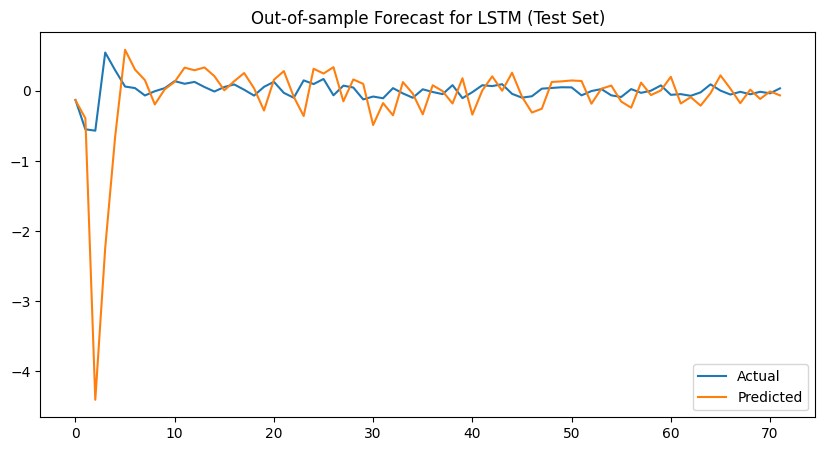

In [22]:
plt.figure(figsize=(10,5))
plt.plot(test_results["actual"], label="Actual")
plt.plot(test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM (Test Set)")
plt.show()

In [23]:
# export test results to csv
#test_results.to_csv('results/lstm_test_results.csv', index=False)


In [24]:
test_results.head()

,test_index,actual,predicted
0,408,-0.129368,-0.134410
1,409,-0.548254,-0.391728
2,410,-0.568125,-4.403046
3,411,0.545621,-2.237060
4,412,0.293704,-0.655051


In [29]:
test_results2 = test_results.iloc[4:].copy()
mse = mean_squared_error(test_results2["actual"], test_results2["predicted"])
r2_2 = r2_score(test_results2["actual"], test_results2["predicted"])
mse, r2_2

(0.05682044392524627, -8.235181162727503)